# Image classification using a ResNet and Regularization techniques in Pytorch

Used techniques:
- data normalization
- data augmentation
- residual connections
- batch normalization
- learning rate annealing
- weight decay
- gradient clipping 


## Preparing the data

In [1]:
import os
import torch
import torchvision
import tarfile
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split

In [2]:
# Extract from archive
with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

The dataset is extracted to the directory data/cifar10. It contains 2 folders train and test, containing the training set (50000 images) and test set (10000 images) respectively. Each of them contains 10 folders, one for each class of images. Let's verify this using os.listdir.

In [3]:
data_dir = './data/cifar10'

In [4]:
print(os.listdir(data_dir))
classes = os.listdir(data_dir + "/train")
print(classes)

['test', 'models', 'train']
['bird', 'truck', 'ship', 'cat', 'frog', 'automobile', 'airplane', 'deer', 'dog', 'horse']


In [5]:
airplane_files = os.listdir(data_dir + "/train/airplane")
print('No. of training examples for airplanes:', len(airplane_files))
print(airplane_files[:5])

No. of training examples for airplanes: 5000
['0338.png', '1720.png', '0693.png', '2505.png', '0292.png']


In [6]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

In [7]:
img, label = ImageFolder(data_dir + "/train", transform=ToTensor())[0]
print(img.shape, label)  # img is a tensor of shape [C, H, W] and label is an integer

torch.Size([3, 32, 32]) 0


We wont separate validation from test - we will validate on the test set (not best practice).

We will normalize and center the data tensors

We will apply randomly chosen transformations while loading images (pad by 4 pixels, take a random crop of size 32x32 pixels, and then flip the image horizontally with a 50% probability.) Since the transformation is applied randomly and dynamically each time, the model sees slightly different images at each epoch of training, which allows it to generalize better.

In [8]:
from torch.utils.data import DataLoader
import torchvision.transforms as tt

# Data augmentation and normalization for training
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))  # mean and std for CIFAR-10
train_tfms = tt.Compose([
    tt.RandomCrop(32, padding=4, padding_mode='reflect'),
    tt.RandomHorizontalFlip(),
    tt.ToTensor(),
    tt.Normalize(*stats)
])

# Data normalization for validation
valid_tfms = tt.Compose([
    tt.ToTensor(),
    tt.Normalize(*stats)
])

#Normalization of the test dataset and validation dataset should be by the same mean and std as the training dataset. This is because we want to ensure that the model sees data that is distributed similarly during both training and evaluation. If we were to use different normalization parameters for the test or validation datasets, it could lead to discrepancies in the model's performance, as it would be evaluated on data that has a different distribution than what it was trained on.

In [9]:
# Pytorch datasets
train_ds = ImageFolder(data_dir + "/train", transform=train_tfms)
valid_ds = ImageFolder(data_dir + "/test", transform=valid_tfms)

Next, we can create DataLoaders to load data in batches.

In [27]:
from torch.utils.data import DataLoader
batch_size = 4

# DataLoaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=8, pin_memory=True) #pin memory=True means that the data loader will copy Tensors into CUDA pinned memory before returning them. This can improve the transfer speed of data from CPU to GPU, especially when using a GPU for training. It is particularly useful when the data loading process is a bottleneck in the training pipeline, as it allows for faster data transfer and can help keep the GPU utilized more effectively.
valid_dl = DataLoader(valid_ds, batch_size, num_workers=8, pin_memory=True)


In [28]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [29]:
def show_batch(dl): 
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
        break

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


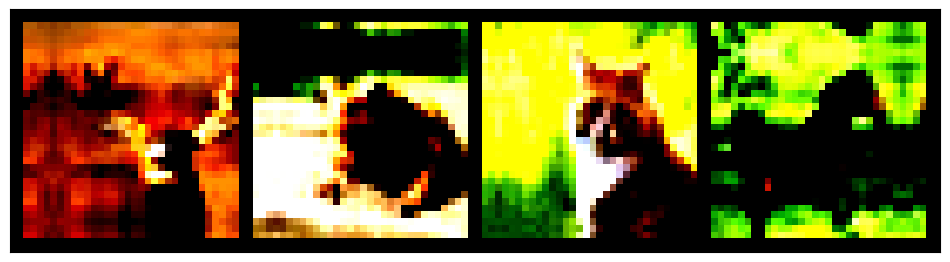

In [30]:
show_batch(train_dl)

In [31]:
# Use a wide ResNet22 model with 22 layers and a width factor of 8. The model is initialized with random weights and trained from scratch on the CIFAR-10 dataset. The model is trained for 10 epochs using the Adam optimizer with a learning rate of 0.001 and a batch size of 256. The training and validation accuracy are monitored during training to evaluate the model's performance.

In [32]:
import torch.nn as nn
import torch.nn.functional as F

In [33]:
class SimpleResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        #self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        #self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential() #this is an identity mapping, which means that the input is passed through unchanged. It is used when the input and output dimensions are the same, so no transformation is needed. In this case, the shortcut connection simply adds the input to the output of the residual block without any modification.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu1(self.conv1(x))
        out = self.relu2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

In [34]:
simple_resnet = SimpleResidualBlock(3, 3)

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break

torch.Size([4, 3, 32, 32])


In [35]:
# Residual means that because we add the input to the output of the block, the network can learn to focus on the residual mapping (the difference between the input and output) rather than trying to learn the entire transformation from scratch. This can make it easier for the network to learn identity mappings, which can help with training deeper networks and mitigate the vanishing gradient problem.

In [36]:
# Learn about batch normalization, which normalizes the output of a previous activation layer by subtracting the batch mean and dividing by the batch standard deviation. This helps to stabilize and accelerate the training of deep neural networks by reducing internal covariate shift. It also allows for higher learning rates and can act as a form of regularization, potentially reducing the need for other regularization techniques like dropout.

In [37]:
def conv_2d(in_channels, out_channels, kernel_size=3, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=kernel_size//2, bias=False) 
# bias is set to False because we are using batch normalization after the convolutional layer. Batch normalization has its own learnable parameters (scale and shift), which can effectively replace the bias term in the convolutional layer. By setting bias=False, we reduce the number of parameters in the model and avoid redundancy, as the batch normalization layer will handle the necessary adjustments to the output of the convolutional layer.

def bn_relu_conv(in_channels, out_channels, kernel_size=3, stride=1):
    return nn.Sequential(
        nn.BatchNorm2d(in_channels),
        nn.ReLU(inplace=True),
        conv_2d(in_channels, out_channels, kernel_size, stride)
    )

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.conv1 = conv_2d(in_channels, out_channels, stride=stride)
        self.conv2 = bn_relu_conv(out_channels, out_channels)

        self.shortcut = lambda x: x  # identity mapping
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                conv_2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn(x), inplace=True)
        r = self.shortcut(out)
        out = self.conv1(out)
        out = self.conv2(out)*0.2 # because the residual block is initialized to be close to an identity mapping, we scale the output of the second convolution by a small factor (0.2) to ensure that the initial output of the block is close to the input. This helps to stabilize training and allows the network to learn more effectively. The scaling factor can be adjusted based on the specific architecture and dataset being used.
        out += r
        return F.relu(out)

In [38]:
def make_group(in_channels, out_channels, num_blocks, stride):
    strides = [stride] + [1]*(num_blocks-1)
    blocks = []
    for stride in strides:
        blocks.append(ResidualBlock(in_channels, out_channels, stride))
        in_channels = out_channels
    return nn.Sequential(*blocks)


class Flatten(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x):
        return x.view(x.size(0), -1)


class WideResNet(nn.Module):
    def __init__(self, depth, scaling_factor, num_classes, num_channels=3, num_blocks_per_group=None, num_groups=3):
        super().__init__()
        # Increase the number of channels in the first convolutional layer to 16, which is a common practice in ResNet architectures. This allows the network to learn more complex features from the input images right from the beginning. The choice of 16 channels is a balance between model capacity and computational efficiency, as it provides enough representational power without making the model too large or slow to train.
        layers = [conv_2d(num_channels, n_start_channels := 16)]
        n_channels = [16]
        # Add group of residual blocks with increasing number of channels and decreasing spatial dimensions. The number of blocks in each group is determined by the depth of the network, and the scaling factor controls the number of channels in each block. The stride is set to 2 for the second and third groups to downsample the feature maps, while the first group maintains the original spatial dimensions. This design allows the network to learn hierarchical features at different scales, which is important for image classification tasks.
        for i in range(num_groups):
            out_channels = 16 * (2**i) * scaling_factor
            stride = 1 if i == 0 else 2
            layers.append(make_group(n_channels[-1], out_channels, num_blocks_per_group[i], stride))
            n_channels.append(out_channels)
        # Pool, flatten and add linear layer for classification. The adaptive average pooling layer reduces the spatial dimensions of the feature maps to 1x1, effectively summarizing the learned features across the entire image. The flatten layer then reshapes the output into a 1D tensor, which is fed into a fully connected linear layer that outputs the final class scores for classification.
        layers.append(nn.BatchNorm2d(n_channels[-1]))
        layers.append(nn.ReLU(inplace=True))
        layers.append(nn.AdaptiveAvgPool2d((1, 1)))
        layers.append(Flatten())
        layers.append(nn.Linear(n_channels[-1], num_classes))
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)


def wrn_22():
    return WideResNet(num_groups=3, num_blocks_per_group=[3, 3, 3], depth=22, scaling_factor=4, num_classes=10)

In [39]:
model = wrn_22()

In [40]:
model

WideResNet(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Sequential(
      (0): ResidualBlock(
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (conv2): Sequential(
          (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (1): ReLU(inplace=True)
          (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (shortcut): Sequential(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (1): ResidualBlock(
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv2d(64, 64, kerne

In [41]:
for images, labels in train_dl:
    out = model(images)
    print(out.shape)
    break

torch.Size([4, 10])


In [42]:
!pip install fastai

In [49]:
from fastai.data.core import DataLoaders
from fastai.learner import Learner
from fastai.metrics import accuracy
from fastai.callback.schedule import *   # <-- enables lr_find, fit_one_cycle, etc.

In [50]:
data = DataLoaders.from_dsets(train_ds, valid_ds, bs=batch_size, device='cuda', path = './data/cifar10')
learner = Learner(data, model, loss_func=nn.CrossEntropyLoss(), metrics=accuracy)
learner.clip = 0.1  # Gradient clipping to prevent exploding gradients during training. This limits the maximum value of the gradients to 0.1, which can help stabilize training and improve convergence, especially in deep networks where gradients can become very large.

<div></div>

SuggestedLRs(valley=0.0003311311302240938)

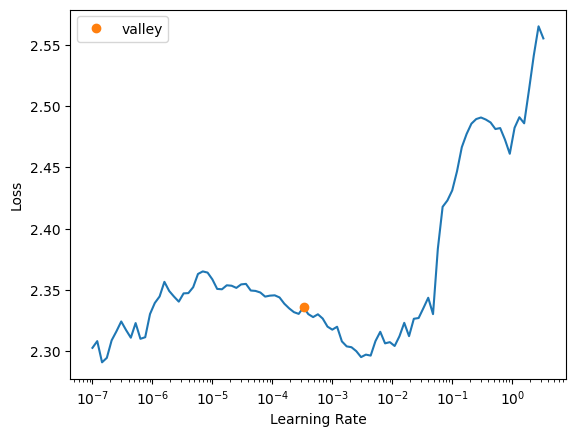

In [ ]:
# Find a good learning rate (reduced batch_size and scaling factor to fit into gpu memory)
learner.lr_find()

In [53]:
# By adding weight decay parameter lambda, the loss becomes:
# Loss + λ * Σ(wᵢ)² 

In [52]:
# one cycle training with a learning rate of 0.0003311311302240938 for 10 epochs
# one cycle training is a learning rate scheduling technique that gradually increases the learning rate from a lower bound to an upper bound and then decreases it back to the lower bound over the course of training. This approach can help the model converge faster and potentially achieve better performance by allowing it to explore different regions of the loss landscape. The specific learning rate value of 0.010.0003311311302240938 is likely determined through experimentation or using a learning rate finder, which helps identify an optimal learning rate for training the model effectively.
learner.fit_one_cycle(10, 0.0003311311302240938, wd=0.0001)  # weight decay of 0.01 is a regularization technique that adds a penalty to the loss function based on the magnitude of the model's weights. This helps prevent overfitting by discouraging the model from relying too heavily on any single feature or weight, promoting better generalization to unseen data. The specific value of 0.01 is a hyperparameter that can be tuned based on the dataset and model architecture.

epoch,train_loss,valid_loss,accuracy,time
0,1.510282,1.345011,0.520300,19:04
1,1.172864,0.904124,0.686700,18:32
2,0.735739,0.739715,0.752100,21:03
3,0.666058,0.591635,0.802700,22:44
4,0.613562,0.507011,0.836000,21:23
5,0.504071,0.450650,0.849100,22:14
6,0.379950,0.377566,0.874100,22:44
7,0.325168,0.402210,0.878600,22:45
8,0.297326,0.358183,0.881900,22:45
9,0.272896,0.352582,0.884300,22:45


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

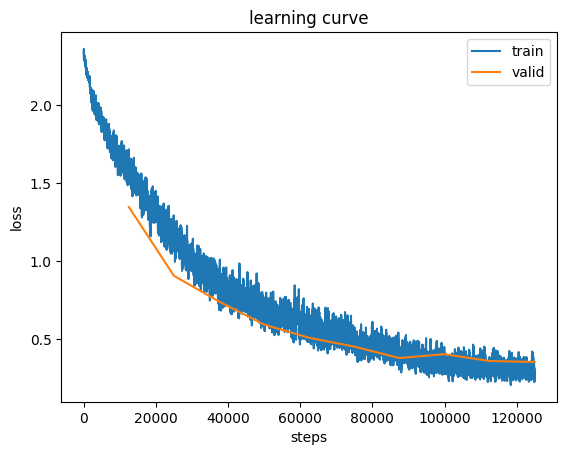

In [54]:
learner.recorder.plot_loss()

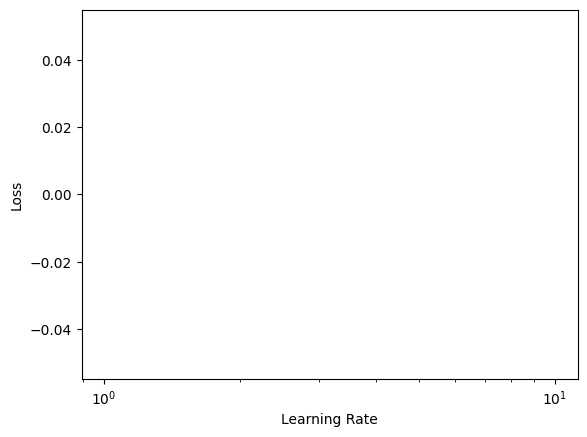

In [59]:
learner.recorder.plot_lr_find()

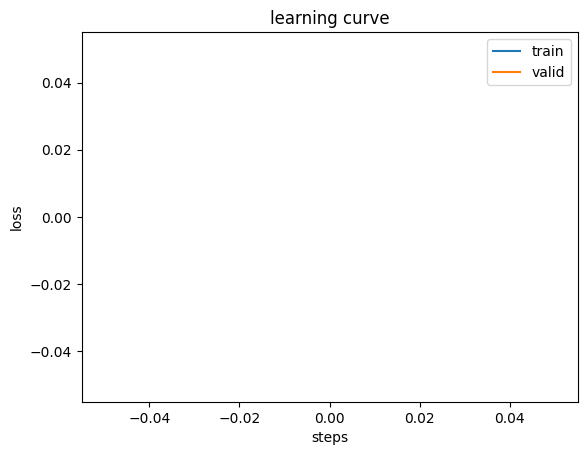

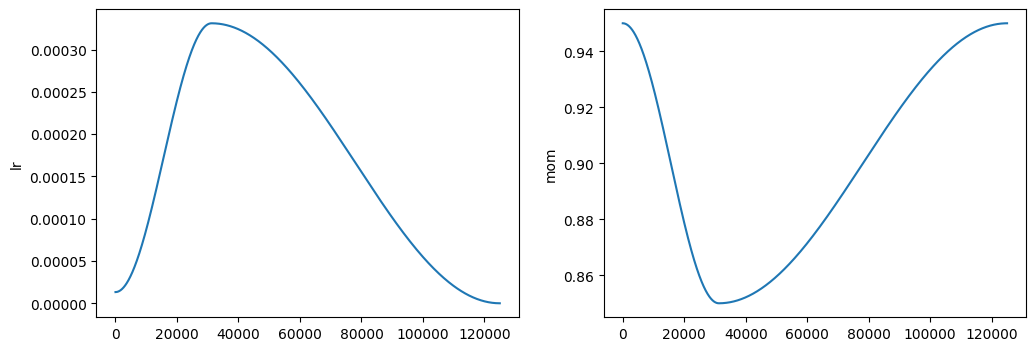

In [60]:
learner.recorder.plot_loss()   # train/valid loss curves over training
learner.recorder.plot_sched()  # hyperparameter schedule (lr, momentum, etc.) over training

In [ ]:
#should have done that before training for fastai to be able to use the fastai Learner class with PyTorch datasets, we need to wrap the datasets in a custom Dataset class that returns the inputs and targets as fastai Tensor types. This is because fastai expects the inputs and targets to be of type TensorImage and TensorCategory, respectively, which are subclasses of PyTorch's Tensor class. By wrapping the datasets in a custom Dataset class, we can ensure that the inputs and targets are returned in the correct format for fastai to work with.

from fastai.torch_core import TensorImage, TensorCategory

class TypedWrapper(torch.utils.data.Dataset):
    def __init__(self, ds): self.ds = ds
    def __len__(self): return len(self.ds)
    def __getitem__(self, i):
        x, y = self.ds[i]
        return TensorImage(x), TensorCategory(y)

train_ds_t = TypedWrapper(train_ds)
valid_ds_t = TypedWrapper(valid_ds)
data = DataLoaders.from_dsets(train_ds_t, valid_ds_t, bs=batch_size)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7692488..2.3440151].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9444429..1.9342991].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.6366696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8506975..2.7537313].


IndexError: index 4 is out of bounds for dimension 0 with size 4

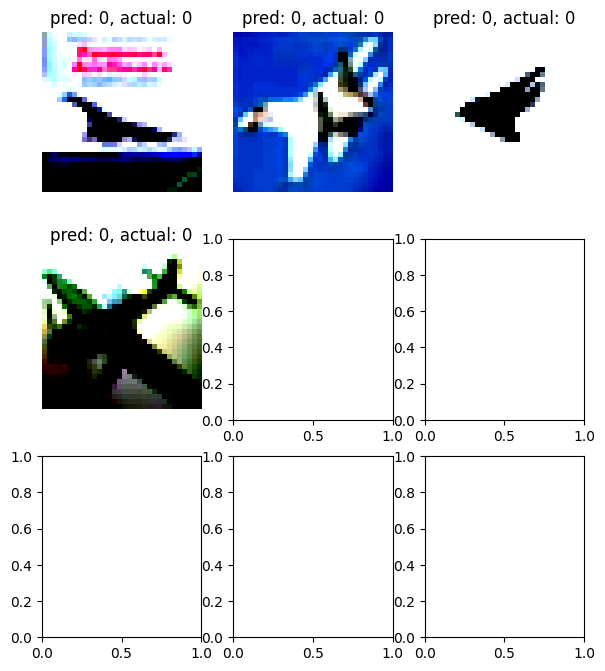

In [63]:
import matplotlib.pyplot as plt

xb, yb = learner.dls.valid.one_batch()
with torch.no_grad():
    preds = learner.model(xb).argmax(dim=1)

fig, axes = plt.subplots(3, 3, figsize=(7, 8))
for i, ax in enumerate(axes.flat):
    img = xb[i].cpu().permute(1, 2, 0)  # C,H,W -> H,W,C
    # undo normalization here if you normalized your inputs, or images will look washed out/inverted
    ax.imshow(img)
    ax.set_title(f'pred: {preds[i].item()}, actual: {yb[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [58]:
torch.save(model.state_dict(), './data/cifar10/wrn_22.pth')